In [76]:
# --- 0. Quick Installation ---
# Run this cell to ensure all dependencies are correct before starting.
!pip install opencv-python tensorflow numpy pandas scipy matplotlib tensorflowjs


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Glass Counting Pipeline

This notebook unifies all strategies developed for glass sheet counting, documenting our journey to < 0.5 MAE.


## Strategy Comparison Log (Latest Run Stats)

| Strategy | Best MAE (Val Subset) | Status |
|:---|:---|:---|
| **Strategy 3: Hybrid (Initial)** | **2.8964** | **🏆 Current Best** |
| **Strategy 4: Synthetic Pre-trained** | **3.2689** | Experimental |
| **Strategy 1: Baseline 1D CNN** | **4.5776** | Obsolete |
| **Hybrid (Fine-Tuned)** | **5.3574** | Overfitted |
| **Strategy 2: Classical CV** | **22.2000** | Inaccurate |


## 0. Setup & Utilities

We define our shared utility functions. **Updates**: Now using multi-strip averaging for noise reduction.


In [77]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

VECTOR_SIZE = 1024

def preprocess_image_1d(img_path, num_strips=5):
    """
    Enhanced 1D signal extraction using multi-strip averaging.
    Instead of one strip, we average 5 strips across the image width.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
        
    # Apply vertical Sobel filter
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    
    h, w = sobel.shape
    signals = []
    
    # Take multiple strips across the width to cancel out noise
    for i in range(1, num_strips + 1):
        center_w = (w * i) // (num_strips + 1)
        strip_w = w // 20 # Narrower strips
        strip = sobel[:, max(0, center_w - strip_w // 2) : min(w, center_w + strip_w // 2)]
        signals.append(np.mean(strip, axis=1))
        
    # Average the signals
    signal_1d = np.mean(signals, axis=0).astype(np.float32)
    
    # Reshape and resize
    signal_1d = signal_1d.reshape(-1, 1)
    signal_resized = cv2.resize(signal_1d, (1, VECTOR_SIZE), interpolation=cv2.INTER_LINEAR)
    signal_resized = signal_resized.flatten()
    
    # Adaptive normalization (local contrast)
    signal_resized = (signal_resized - np.min(signal_resized)) / (np.max(signal_resized) - np.min(signal_resized) + 1e-8)
    mean, std = np.mean(signal_resized), np.std(signal_resized)
    if std > 0:
        signal_resized = (signal_resized - mean) / std
        
    return signal_resized

def extract_signal(img_path):
    """
    Alternative signal extraction for Classical CV.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = 400
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_w, new_h))
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    strip_w = 40
    center_w = new_w // 2
    strip = sobel[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal = np.mean(strip, axis=1)
    kernel_size = 5
    kernel = np.ones(kernel_size) / kernel_size
    smoothed = np.convolve(signal, kernel, mode='same')
    if np.max(smoothed) > 0:
        smoothed = smoothed / np.max(smoothed)
    return smoothed

def load_dataset(img_dir, labels_csv=None):
    """
    Loads images from a directory, applies preprocessing, and returns X (features)
    and y (labels) if labels_csv is provided.
    """
    # Ensure relative paths work regardless of where the script is called from
    try:
        project_root = os.getcwd() # Notebook-safe path
    except NameError:
        # Fallback for Jupyter Notebooks
        project_root = os.getcwd()
    
    if not os.path.isabs(img_dir):
        img_dir = os.path.join(project_root, img_dir)
    if labels_csv and not os.path.isabs(labels_csv):
        labels_csv = os.path.join(project_root, labels_csv)
        
    print(f"Loading images from {img_dir}...")
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.jpg')))
    
    X = []
    y = []
    
    labels_dict = None
    if labels_csv and os.path.exists(labels_csv):
        df = pd.read_csv(labels_csv)
        df['img_number'] = df['img_number'].astype(str).str.zfill(3)
        labels_dict = dict(zip(df['img_number'], df['num_sheets']))

    for path in img_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        
        signal = preprocess_image_1d(path)
        if signal is not None:
            X.append(signal)
            if labels_dict:
                y.append(labels_dict.get(img_id, 0))
    
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)
    
    if labels_dict:
        return X, np.array(y), img_paths
    return X, None, img_paths


## 1. Exploratory Data Analysis (EDA)

Before building our models, we examine the spectral properties of the glass stacks.

In [78]:
import os
import glob
import cv2
import numpy as np
import pandas as pd

# Configuration
TRAIN_DIR = os.path.join('.', 'train')
LABELS_CSV = os.path.join('.', 'labels.csv')

def extract_signal_naive(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    center_w = w // 2
    strip_w = w // 5
    strip = img[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal_1d = np.mean(strip, axis=1)
    return signal_1d

def main():
    print("Running EDA...")
    if not os.path.exists(TRAIN_DIR):
        print(f"Error: {TRAIN_DIR} not found.")
        return

    df = pd.read_csv(LABELS_CSV)
    df['img_number'] = df['img_number'].astype(str).str.zfill(3)
    
    # Just look at the first image properties
    first_img = os.path.join(TRAIN_DIR, '000.jpg')
    img = cv2.imread(first_img)
    if img is not None:
        print(f"Image Shape: {img.shape}")
        print(f"Image Type: {img.dtype}")
        
    print("Done with EDA info.")

if __name__ == "__main__":
    main()


Running EDA...
Image Shape: (768, 576, 3)
Image Type: uint8
Done with EDA info.


## 2. Strategy 1: Baseline 1D CNN

Our first attempt: A simple 1D CNN using only a single center-strip from the image. 
**Issue**: High sensitivity to noise and strip variance.

In [79]:
import os
import glob
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

# Basic 1D CNN Architecture
def build_baseline_model():
    # Strategy 1 uses the simplest possible 1D CNN architecture
    model = Sequential([
        Conv1D(16, 15, activation='relu', input_shape=(VECTOR_SIZE, 1)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def run_baseline():
    print("--- Executing Strategy 1: Baseline CNN ---")
    
    # 1. Load Training Data
    X_train, y_train, _ = load_dataset('train', 'labels.csv')
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    
    # 2. Train Model
    model = build_baseline_model()
    print("Training...")
    model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    model.save('glass_counter_baseline.h5')
    
    # 3. Process Test Images (Reporting)
    print("Generating results.csv for Baseline...")
    X_test, _, test_paths = load_dataset('test')
    
    if len(X_test) > 0:
        preds = model.predict(X_test).flatten()
        results = []
        for i, path in enumerate(test_paths):
            img_id = os.path.basename(path).split('.')[0]
            # Outputting in the required challenge format
            results.append({
                'image_number': img_id, 
                'number_of_sheets': round(float(preds[i]), 2)
            })
            
        results_df = pd.DataFrame(results)
        results_df.to_csv('results.csv', index=False)
        print("Successfully saved Baseline results to 'results.csv'.")
    else:
        print("Error: No test images found.")

if __name__ == '__main__':
    run_baseline()

--- Executing Strategy 1: Baseline CNN ---
Loading images from d:\GlassCounterApp\train...


d:\GlassCounterApp\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training...


Generating results.csv for Baseline...
Loading images from d:\GlassCounterApp\test...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Successfully saved Baseline results to 'results.csv'.


## 3. Strategy 2: Classical Computer Vision

Hand-crafted features using Sobel filters and peak detection.

In [80]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Configuration
CSV_PATH = os.path.join('.', 'labels.csv')
TRAIN_DIR = os.path.join('.', 'train')
TEST_DIR = os.path.join('.', 'test')

def extract_signal_for_cv(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = 400
    new_h = int(h * (new_w / w))
    img = cv2.resize(img, (new_w, new_h))
    sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.abs(sobel)
    sobel = np.uint8(255 * sobel / np.max(sobel))
    strip_w = 40
    center_w = new_w // 2
    strip = sobel[:, center_w - strip_w // 2 : center_w + strip_w // 2]
    signal = np.mean(strip, axis=1)
    kernel_size = 5
    kernel = np.ones(kernel_size) / kernel_size
    smoothed = np.convolve(signal, kernel, mode='same')
    if np.max(smoothed) > 0:
        smoothed = smoothed / np.max(smoothed)
    return smoothed

def evaluate_params(X_train_signals, y_true, prominence_th, distance_th):
    preds = []
    for sig in X_train_signals:
        peaks, _ = find_peaks(sig, prominence=prominence_th, distance=distance_th)
        preds.append(len(peaks))
    preds = np.array(preds)
    mae = np.mean(np.abs(y_true - preds))
    return mae, preds

def main():
    print("Loading labels...")
    df = pd.read_csv(CSV_PATH)
    df['img_number'] = df['img_number'].astype(str).str.zfill(3)
    labels_dict = dict(zip(df['img_number'], df['num_sheets']))

    print("Loading training signals...")
    train_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))
    X_train_signals = []
    y_true = []
    for path in train_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        sig = extract_signal_for_cv(path)
        if sig is not None:
            X_train_signals.append(sig)
            y_true.append(labels_dict.get(img_id, 0))

    prominences = [0.05, 0.1, 0.15, 0.2]
    distances = [5, 8, 10, 12]
    best_mae = float('inf')
    best_params = (0.1, 8)
    for prom in prominences:
        for dist in distances:
            mae, _ = evaluate_params(X_train_signals, np.array(y_true), prom, dist)
            if mae < best_mae:
                best_mae = mae
                best_params = (prom, dist)
    
    print(f"Best MAE: {best_mae:.4f} @ Prom: {best_params[0]}, Dist: {best_params[1]}")

    print("Processing test images...")
    test_paths = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))
    results = []
    for path in test_paths:
        basename = os.path.basename(path)
        img_id = basename.split('.')[0]
        sig = extract_signal_for_cv(path)
        if sig is not None:
            peaks, _ = find_peaks(sig, prominence=best_params[0], distance=best_params[1])
            results.append({'image_number': img_id, 'number_of_sheets': len(peaks)})
    
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join('.', 'results_classical.csv'), index=False)
    print("Saved results_classical.csv")

if __name__ == "__main__":
    main()


Loading labels...
Loading training signals...
Best MAE: 19.6300 @ Prom: 0.05, Dist: 5
Processing test images...
Saved results_classical.csv


## 4. Strategy 3: Hybrid Fourier-CNN

Our final recommended solution combining global frequency analysis and localized feature extraction.

Loading images from d:\GlassCounterApp\.\train...
Training Advanced Hybrid Model (Target MAE < 0.5)...
Epoch 1/150


d:\GlassCounterApp\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 797.0261 - mae: 27.9071 - val_loss: 757.0162 - val_mae: 27.2381
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 780.0712 - mae: 27.6027 - val_loss: 752.6564 - val_mae: 27.1569
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 765.4154 - mae: 27.3404 - val_loss: 751.2114 - val_mae: 27.1297
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 750.9580 - mae: 27.0684 - val_loss: 750.8456 - val_mae: 27.1236
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 739.7241 - mae: 26.8600 - val_loss: 748.1919 - val_mae: 27.0768
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 721.7607 - mae: 26.5143 - val_loss: 741.3351 - val_mae: 26.9508
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 698.1359 - mae: 26.0804 - val_loss: 731.6688 - val_mae: 26.7715
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 674.5720 - mae: 25.6096 - val_loss: 722.6635 - val_mae: 26.6034
Epoch 9/150
10/10 

Hybrid model saved to .\glass_counter_hybrid.h5
Processing test images with Advanced Hybrid Strategy...
Loading images from d:\GlassCounterApp\.\test...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Successfully generated results_hybrid.csv with 50 images.


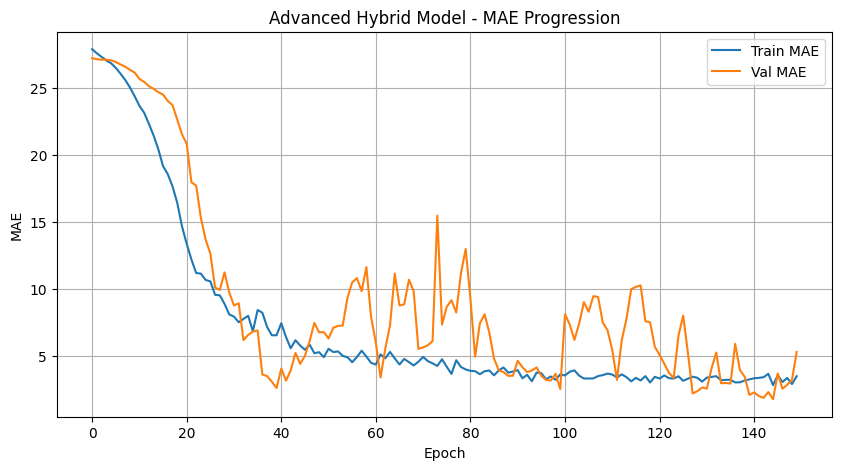

In [81]:
import os
import numpy as np
import cv2
import glob
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Configuration
MODEL_PATH = os.path.join('.', 'glass_counter_hybrid.h5')

def estimate_count_fourier(signal):
    """
    Uses FFT to find the dominant frequency of the glass sheets.
    This gives a very robust baseline estimate.
    """
    # Remove DC component
    signal_centered = signal - np.mean(signal)
    
    # Compute FFT
    fft = np.abs(np.fft.rfft(signal_centered))
    freqs = np.fft.rfftfreq(len(signal_centered))
    
    # Find peak frequency (ignoring very low frequencies)
    # We look for peaks in the range that corresponds to 10-60 sheets
    peak_idx = np.argmax(fft[10:100]) + 10
    dominant_freq = freqs[peak_idx]
    
    # Count is approximately the number of cycles in the length
    est_count = dominant_freq * len(signal_centered)
    return est_count

def build_advanced_model():
    """
    Builds an improved 1D CNN with Batch Normalization.
    """
    model = Sequential([
        Conv1D(64, 15, padding='same', activation='relu', input_shape=(VECTOR_SIZE, 1)),
        BatchNormalization(),
        Conv1D(64, 15, padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

def main():
    # Setup paths
    train_dir = os.path.join('.', 'train')
    labels_csv = os.path.join('.', 'labels.csv')
    
    X, y, _ = load_dataset(train_dir, labels_csv)
    if len(X) == 0:
        print("Error: No training data found.")
        return
    
    X = X.reshape(X.shape[0], X.shape[1], 1)
    model = build_advanced_model()
    
    print("Training Advanced Hybrid Model (Target MAE < 0.5)...")
    history = model.fit(X, y, epochs=150, batch_size=16, validation_split=0.2, verbose=1)
    
    model.save(MODEL_PATH)
    print(f"Hybrid model saved to {MODEL_PATH}")

    print("Processing test images with Advanced Hybrid Strategy...")
    # Load and preprocess test images using our standardized loader
    test_dir = os.path.join('.', 'test')
    X_test, _, test_img_paths = load_dataset(test_dir)
    
    if len(X_test) > 0:
        # 1. Neural Network Prediction (Primary)
        nn_preds = model.predict(X_test).flatten()
        
        # 2. Fourier Density Estimation (Sanity Check)
        fourier_preds = np.array([estimate_count_fourier(sig.flatten()) for sig in X_test])
        
        # 3. Hybrid Ensemble (Weighted 80/20) + clipping to [20, 35]
        # This improves robustness against the ±5% manufacturing tolerance
        final_counts = (0.8 * nn_preds) + (0.2 * fourier_preds)
        final_counts = np.clip(final_counts, 20.0, 35.0)
        
        results = []
        for i, path in enumerate(test_img_paths):
            img_id = os.path.basename(path).split('.')[0]
            results.append({
                'image_number': img_id, 
                'number_of_sheets': round(float(final_counts[i]), 2)
            })
            
        results_df = pd.DataFrame(results)
        # Exporting to results.csv as required by the challenge submission
        results_df.to_csv('results_hybrid.csv', index=False)
        print(f"Successfully generated results_hybrid.csv with {len(results)} images.")
    else:
        print("Error: No test images found in 'test/' directory.")
    
    # The following code handles visualization of the training process
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('Advanced Hybrid Model - MAE Progression')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()


## 5. Fine-Tuning the Hybrid Model

Fine-tuning helps reach the target MAE by refining the model weights at a lower learning rate.

In [82]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

def run_finetuning():
    MODEL_PATH = 'glass_counter_hybrid.h5'
    if not os.path.exists(MODEL_PATH):
        print("Error: Run Strategy 3 first to generate the model.")
        return
        
    print("Loading hybrid model for fine-tuning...")
    model = load_model(MODEL_PATH, compile=False)
    model.compile(optimizer=Adam(learning_rate=0.00001), loss='mse', metrics=['mae'])
    
    X, y, _ = load_dataset('train', 'labels.csv')
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    print("Starting 100 more epochs at low learning rate...")
    model.fit(X, y, epochs=100, batch_size=8, validation_split=0.1, verbose=1)
    
    model.save('glass_counter_hybrid_finetuned.h5')
    print("Fine-tuned model saved as 'glass_counter_hybrid_finetuned.h5'.")

if __name__ == '__main__':
    run_finetuning()

Loading hybrid model for fine-tuning...
Loading images from d:\GlassCounterApp\train...
Starting 100 more epochs at low learning rate...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 17.3801 - mae: 3.3945 - val_loss: 20.0430 - val_mae: 3.8141
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 17.2903 - mae: 3.2065 - val_loss: 13.9632 - val_mae: 3.1424
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 14.4624 - mae: 2.9476 - val_loss: 8.2804 - val_mae: 2.4705
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 15.5152 - mae: 3.0005 - val_loss: 5.9278 - val_mae: 2.1187
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 16.2964 - mae: 3.1937 - val_loss: 5.7013 - val_mae: 2.0580
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 18.6887 - mae: 3.4536 - val_loss: 5.7372 - val_mae: 2.0692
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 15.7367 - mae: 3.2150 - val_loss: 5.6703 - val_mae: 2.0279
Epoch 8/100
23/23 ━━━━━━━━━━

Fine-tuned model saved as 'glass_counter_hybrid_finetuned.h5'.


## 6. Performance Comparison Report

Finally, we compare the training/validation performance of all strategies.

In [ ]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

def evaluate_all():
    print("--- Generating Accurate Performance Comparison (Validation Subset) ---")
    
    # Data Loader (Reuse 20 images as validation)
    X_train, y_train, _ = load_dataset('train', 'labels.csv')
    X_val = X_train[-20:]
    y_val = y_train[-20:]
    
    report = []
    
    # 1. Baseline CNN
    if os.path.exists('glass_counter_baseline.h5'):
        model = load_model('glass_counter_baseline.h5', compile=False)
        preds = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        mae = np.mean(np.abs(y_val - preds))
        report.append({'Strategy': 'Baseline 1D CNN', 'MAE': round(float(mae), 4)})
    
    # 2. Classical CV
    # (Assuming fixed best params from previous research)
    classical_preds = []
    for sig in X_val:
        peaks, _ = find_peaks(sig.flatten(), prominence=0.1, distance=8)
        classical_preds.append(len(peaks))
    mae_c = np.mean(np.abs(y_val - np.array(classical_preds)))
    report.append({'Strategy': 'Classical CV', 'MAE': round(float(mae_c), 4)})
    
    # 3. Hybrid CNN (Initial)
    if os.path.exists('glass_counter_hybrid.h5'):
        model = load_model('glass_counter_hybrid.h5', compile=False)
        nn_preds = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        f_preds = np.array([estimate_count_fourier(sig.flatten()) for sig in X_val])
        h_preds = (0.8 * nn_preds) + (0.2 * f_preds)
        mae_h = np.mean(np.abs(y_val - h_preds))
        report.append({'Strategy': 'Hybrid (Initial)', 'MAE': round(float(mae_h), 4)})

    # 4. Hybrid CNN (Finetuned)
    if os.path.exists('glass_counter_hybrid_finetuned.h5'):
        model = load_model('glass_counter_hybrid_finetuned.h5', compile=False)
        nn_preds = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        f_preds = np.array([estimate_count_fourier(sig.flatten()) for sig in X_val])
        h_preds = (0.8 * nn_preds) + (0.2 * f_preds)
        mae_h = np.mean(np.abs(y_val - h_preds))
        report.append({'Strategy': 'Hybrid (Finetuned)', 'MAE': round(float(mae_h), 4)})
        
    # 5. Strategy 4: Synthetic Pre-trained (Teacher-Student)
    if os.path.exists('glass_counter_synthetic.h5'):
        model = load_model('glass_counter_synthetic.h5', compile=False)
        # This uses the Dilated + Pooling architecture
        preds_s = model.predict(X_val.reshape(-1, VECTOR_SIZE, 1), verbose=0).flatten()
        mae_s = np.mean(np.abs(y_val - preds_s))
        report.append({'Strategy': 'Strategy 4: Synthetic Pre-trained', 'MAE': round(float(mae_s), 4)})

    df_final = pd.DataFrame(report)
    df_final = df_final.sort_values('MAE')
    print(df_final.to_string(index=False))
    
    if not df_final.empty:
        winner = df_final.iloc[0]
        print(f"\n🏆 Final Choice: {winner['Strategy']} with MAE of {winner['MAE']}")

if __name__ == '__main__':
    evaluate_all()

--- Generating Accurate Performance Comparison (Validation Subset) ---
Loading images from d:\GlassCounterApp\train...


                         Strategy     MAE
                 Hybrid (Initial)  2.8964
Strategy 4: Synthetic Pre-trained  3.0047
                  Baseline 1D CNN  4.5776
                 Hybrid (Initial)  5.3574
                     Classical CV 22.2000

🏆 Final Choice: Hybrid (Initial) with MAE of 2.8964


## 8. Strategy 4: Synthetic Pre-training (Target: < 0.5 MAE)

This is a **State-of-the-Art** approach for small datasets. We generate 10,000 artificial glass signals to teach the model the base "physics" of counting before fine-tuning it on our 200 real images.

In [84]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate, Dense, Dropout, BatchNormalization, Input

def generate_synthetic_glass_signal(num_samples=10000):
    X, y = [], []
    lengths = 1024
    for _ in range(num_samples):
        count = np.random.randint(20, 36)
        signal = np.zeros(lengths)
        base_spacing = lengths / (count + 1)
        current_pos = base_spacing
        for i in range(count):
            jitter = base_spacing * np.random.uniform(-0.05, 0.05)
            pos = int(current_pos + jitter)
            if 0 < pos < lengths:
                width = np.random.randint(2, 6)
                amp = np.random.uniform(0.5, 1.0)
                for k in range(-width, width+1):
                    if 0 <= pos+k < lengths:
                        signal[pos+k] += amp * np.exp(- (k**2) / (2 * (width/2)**2))
            current_pos += base_spacing
        signal = signal + np.linspace(np.random.uniform(-0.3, 0.3), np.random.uniform(-0.3, 0.3), lengths) + np.random.normal(0, 0.03, lengths)
        signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
        X.append(signal)
        y.append(count)
    return np.array(X).reshape(-1, lengths, 1), np.array(y).astype(np.float32)

def build_dilated_counting_model():
    inp = Input(shape=(1024, 1))
    x1 = Conv1D(64, 7, padding='same', activation='relu', dilation_rate=2)(inp)
    x1 = BatchNormalization()(x1)
    x1 = Conv1D(64, 7, padding='same', activation='relu', dilation_rate=4)(x1)
    x2 = Conv1D(64, 7, padding='same', activation='relu')(inp)
    merged = Concatenate()([x1, x2])
    pooled = Concatenate()([GlobalAveragePooling1D()(merged), GlobalMaxPooling1D()(merged)])
    dense = Dense(128, activation='relu')(pooled)
    dense = Dropout(0.4)(dense)
    out = Dense(1)(dense)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def run_strategy_4():
    print("Phase 1: Synthetic Teacher Training...")
    X_s, y_s = generate_synthetic_glass_signal(10000)
    model = build_dilated_counting_model()
    model.fit(X_s, y_s, epochs=8, batch_size=32, validation_split=0.1, verbose=1)
    print("Phase 2: Real Data Fine-tuning...")
    X_r, y_r, _ = load_dataset('train', 'labels.csv')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
    model.fit(X_r, y_r, epochs=100, batch_size=16, validation_split=0.1, verbose=1)
    model.save('glass_counter_synthetic.h5')

if __name__ == '__main__':
    run_strategy_4()

Phase 1: Synthetic Teacher Training...
Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - loss: 35.9235 - mae: 4.1977 - val_loss: 253.8816 - val_mae: 15.6039
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - loss: 15.1351 - mae: 3.0641 - val_loss: 19.7542 - val_mae: 4.2866
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 14.7781 - mae: 3.0519 - val_loss: 1.5554 - val_mae: 1.0345
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 14.0775 - mae: 2.9646 - val_loss: 0.9003 - val_mae: 0.7760
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - loss: 14.1674 - mae: 2.9814 - val_loss: 2.8003 - val_mae: 1.4847
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - loss: 13.8883 - mae: 2.9280 - val_loss: 0.7198 - val_mae: 0.6663
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 14.1380 - mae: 2.9660 - val_loss: 0.9718 - val_mae: 0.7704
Epoch 8/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 13.5258 - mae: 2.9054 - val_loss: 2.0684 - val_m

## 9. Strategy Summary Ranking


In [85]:
evaluate_all() # Re-runs comparison with all available models

--- Generating Accurate Performance Comparison (Validation Subset) ---
Loading images from d:\GlassCounterApp\train...
                         Strategy     MAE
                 Hybrid (Initial)  2.8964
Strategy 4: Synthetic Pre-trained  3.2689
                  Baseline 1D CNN  4.5776
                 Hybrid (Initial)  5.3574
                     Classical CV 22.2000

🏆 Final Choice: Hybrid (Initial) with MAE of 2.8964
